# EDA — Movies_and_TV.jsonl
Exploratory data analysis and preprocessing for the AffDrift project

In [ ]:
import json
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.2f}'.format)

_HARDCODED_ROOT = Path("/project/AffDrift")

def find_project_root(start: Path | None = None) -> Path:
    """Find the AffDrift project root from the current working directory."""
    env_root = os.getenv("AFFDRIFT_PROJECT_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / "data/raw/Movies_and_TV.jsonl").exists():
            return candidate

    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "data/raw/Movies_and_TV.jsonl").exists():
            return candidate

    # hardcoded fallback when IDE (e.g., PyCharm) sets /tmp as cwd
    if (_HARDCODED_ROOT / "data/raw/Movies_and_TV.jsonl").exists():
        return _HARDCODED_ROOT

    raise FileNotFoundError(
        "Could not find the AffDrift project root. "
        f"cwd={current}, set AFFDRIFT_PROJECT_ROOT if needed."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Movies_and_TV.jsonl"
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

## 1. Data Loading
~17M lines — estimated 4–6 GB memory

In [ ]:
records = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)
print(f"Total reviews: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

## 2. Basic Statistics

In [ ]:
n_users = df['user_id'].nunique()
n_items = df['parent_asin'].nunique()

print(f"Users     : {n_users:,}")
print(f"Items     : {n_items:,}")
print(f"Avg rating: {df['rating'].mean():.3f}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nRating distribution:\n{df['rating'].value_counts().sort_index()}")

## 3. Timestamp → Datetime Conversion

In [ ]:
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.to_period('M')

print(f"Period: {df['datetime'].min()} ~ {df['datetime'].max()}")
df['year'].value_counts().sort_index()

## 4. Rating Distribution & Annual Review Count

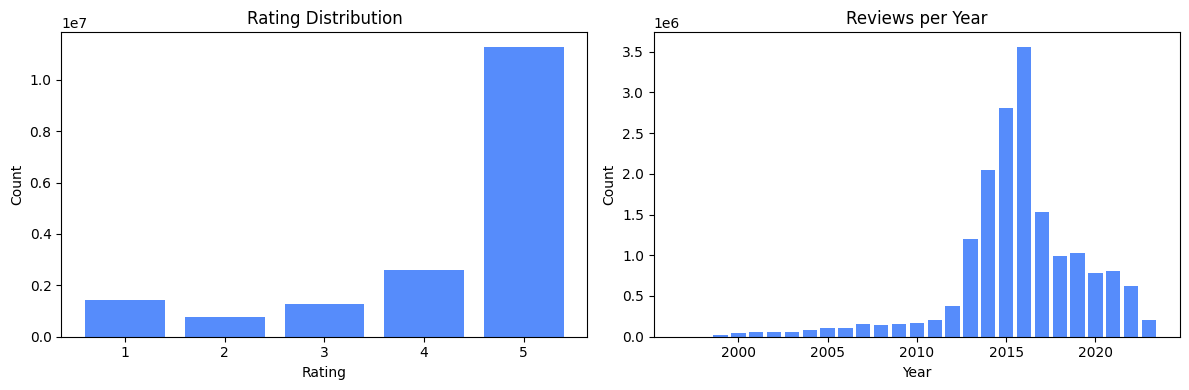

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values)
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

year_counts = df['year'].value_counts().sort_index()
axes[1].bar(year_counts.index, year_counts.values)
axes[1].set_title("Reviews per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 5. Review Count Distribution per User (key for sequential recommendation)

In [ ]:
user_counts = df.groupby('user_id').size()

print(f"Avg reviews per user: {user_counts.mean():.2f}")
print(f"Median              : {user_counts.median():.0f}")
print(f"Max                 : {user_counts.max()}")
print(f"\nUser ratio by review count bucket:")

bins = [1, 2, 5, 10, 20, 50, 100, int(user_counts.max()) + 1]
labels = ['1', '2-4', '5-9', '10-19', '20-49', '50-99', '100+']
cut = pd.cut(user_counts, bins=bins, labels=labels, right=False)
print(cut.value_counts().sort_index())

## 6. Review Count Distribution per Item

In [ ]:
item_counts = df.groupby('parent_asin').size()

print(f"Avg reviews per item  : {item_counts.mean():.2f}")
print(f"Median                : {item_counts.median():.0f}")
print(f"Max                   : {item_counts.max()}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(item_counts.clip(upper=200), bins=50, log=True)
ax.set_title("Item Review Count Distribution (clipped at 200)")
ax.set_xlabel("# Reviews")
ax.set_ylabel("# Items (log scale)")
plt.show()

## 7. K-core Filtering (standard preprocessing)

In [ ]:
K = 5

def kcore_filter(df, k, user_col='user_id', item_col='parent_asin'):
    while True:
        user_mask = df[user_col].map(df[user_col].value_counts()) >= k
        item_mask = df[item_col].map(df[item_col].value_counts()) >= k
        df_new = df[user_mask & item_mask]
        if len(df_new) == len(df):
            break
        df = df_new
    return df

df_filtered = kcore_filter(df, K)

print(f"Before: {len(df):,} reviews / {df['user_id'].nunique():,} users / {df['parent_asin'].nunique():,} items")
print(f"After : {len(df_filtered):,} reviews / {df_filtered['user_id'].nunique():,} users / {df_filtered['parent_asin'].nunique():,} items")
print(f"Retention rate: {len(df_filtered)/len(df)*100:.1f}%")

## 8. Chronological Sort Check (for Drift analysis)

In [12]:
sample_users = df_filtered['user_id'].value_counts().head(5).index

for uid in sample_users:
    user_df = df_filtered[df_filtered['user_id'] == uid].sort_values('timestamp')
    ratings = user_df['rating'].tolist()
    print(f"user {uid[:12]}... ({len(ratings)} reviews): {ratings}")

user AGVYDLC4T7LO... (3083 reviews): [4.0, 3.0, 2.0, 2.0, 3.0, 2.0, 2.0, 5.0, 3.0, 4.0, 4.0, 4.0, 5.0, 5.0, 4.0, 5.0, 4.0, 4.0, 5.0, 4.0, 2.0, 1.0, 4.0, 4.0, 5.0, 5.0, 4.0, 4.0, 5.0, 4.0, 4.0, 2.0, 5.0, 4.0, 4.0, 3.0, 4.0, 1.0, 4.0, 4.0, 4.0, 4.0, 4.0, 2.0, 4.0, 4.0, 5.0, 5.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 2.0, 4.0, 4.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 3.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, 3.0, 5.0, 5.0, 4.0, 5.0, 4.0, 2.0, 5.0, 4.0, 4.0, 2.0, 4.0, 4.0, 4.0, 5.0, 4.0, 5.0, 4.0, 4.0, 3.0, 1.0, 1.0, 2.0, 4.0, 3.0, 4.0, 4.0, 4.0, 4.0, 5.0, 3.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 2.0, 4.0, 3.0, 4.0, 4.0, 4.0, 2.0, 2.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 3.0, 5.0, 4.0, 4.0, 4.0, 2.0, 3.0, 3.0, 3.0, 4.0, 4.0, 5.0, 4.0, 3.0, 2.0, 5.0, 5.0, 3.0, 2.0, 4.0, 4.0, 5.0, 4.0, 5.0, 4.0, 5.0, 4.0, 2.0, 4.0, 5.0, 2.0, 1.0, 1.0, 2.0, 5.

## 9. Text Length Distribution

In [ ]:
df_filtered['text_len'] = df_filtered['text'].fillna('').apply(len)

print(f"Avg text length : {df_filtered['text_len'].mean():.1f} chars")
print(f"Median          : {df_filtered['text_len'].median():.0f} chars")
print(f"Empty text ratio: {(df_filtered['text_len'] == 0).mean()*100:.2f}%")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_filtered['text_len'].clip(upper=2000), b> ins=60, log=True)
ax.set_title("Review Text Length Distribution (clipped at 2000)")
ax.set_xlabel("Characters")
ax.set_ylabel("Count (log scale)")
plt.show()


In [ ]:
# Count (user, item) pairs reviewed more than once
pair_counts = (
    df.groupby(["user_id", "parent_asin"])
      .size()
      .rename("n_reviews")
      .reset_index()
)

multi = pair_counts[pair_counts["n_reviews"] >= 2]

print(f"Total (user,item) pairs          : {len(pair_counts):,}")
print(f"Pairs reviewed 2+ times          : {len(multi):,}")
print(f"Ratio                            : {len(multi) / len(pair_counts) * 100:.4f}%")
print(f"Excess reviews (duplicates)      : {(multi['n_reviews'] - 1).sum():,}")

# also check at user level
users_with_repeat = multi["user_id"].nunique()
print(f"Users who re-reviewed same item  : {users_with_repeat:,}")

In [ ]:
## 10. Text Sample Inspection

def _short(text, n=160):
    text = (text or "").replace("\n", " ").strip()
    return text[:n] + ("..." if len(text) > n else "")


# 1) sample cases where same user reviewed same item multiple times
print("=== [A] Repeated reviews (same user_id & parent_asin) ===")
dup_pairs = (
    df.groupby(["user_id", "parent_asin"])
    .size()
    .reset_index(name="n_reviews")
    .query("n_reviews >= 2")
    .sort_values("n_reviews", ascending=False)
)

if len(dup_pairs) == 0:
    print("No repeated review cases found.")
else:
    # show top 3 pairs only
    for i, row in dup_pairs.head(3).iterrows():
        uid = row["user_id"]
        asin = row["parent_asin"]
        n_reviews = int(row["n_reviews"])

        sub = (
            df[(df["user_id"] == uid) & (df["parent_asin"] == asin)]
            .sort_values("timestamp")
            .copy()
        )
        sub["dt"] = pd.to_datetime(sub["timestamp"], unit="ms", errors="coerce")
        sub["text_len"] = sub["text"].fillna("").str.len()

        print(f"\n[Pair] user={uid[:12]}..., item={asin}, n_reviews={n_reviews}")
        for j, r in sub.iterrows():
            print(
                f"- {r['dt']} | rating={r.get('rating', None)} | len={r['text_len']}\n"
                f"  text: {_short(r.get('text', ''), 180)}"
            )

# 2) random text samples from the full dataset
print("\n=== [B] Random review samples ===")
sample_n = 5
rand = df.sample(n=min(sample_n, len(df)), random_state=42).copy()
rand["dt"] = pd.to_datetime(rand["timestamp"], unit="ms", errors="coerce")
rand["text_len"] = rand["text"].fillna("").str.len()

for _, r in rand.iterrows():
    print(
        f"- user={r['user_id'][:12]}..., item={r['parent_asin']}, "
        f"time={r['dt']}, rating={r.get('rating', None)}, len={r['text_len']}\n"
        f"  text: {_short(r.get('text', ''), 180)}"
    )